## 0. CONFIGURACIÓN INICIAL
### 0.1 Importar librerías

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import random
import os
import warnings
warnings.filterwarnings('ignore')



print("Versión de TensorFlow:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # Para verificar GPU

I0000 00:00:1773561476.674862     944 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Versión de TensorFlow: 2.21.0
Num GPUs Available:  1



### 0.2. Configuración de Semillas y Parámetros Globales

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_WIDTH = 32  
IMAGE_HEIGHT = 32 
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS = 3
BATCH_SIZE = 64  
EPOCHS_SCRATCH = 30 
EPOCHS_TRANSFER = 20

# Nombres de las clases en CIFAR-10
CLASS_NAMES = ['Avión', 'Coche', 'Pájaro', 'Gato', 'Ciervo', 
               'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

### 0.3. Definición de Rutas (si aplica) - En Google Colab

### 0.4. Funciones Auxiliares (Ejemplo: Plotear Curvas)

In [3]:
def plot_learning_curves(history, title_suffix=''):
    """Plotea las curvas de loss y accuracy para entrenamiento y validación."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Inicializamos la figura de forma sencilla
    plt.figure(figsize=(12, 4))
    
    # Subplot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.legend(loc='lower right')
    plt.title(f'Accuracy {title_suffix}')
    plt.grid(True)

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.legend(loc='upper right')
    plt.title(f'Loss {title_suffix}')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title)
    ax.set_ylabel('Etiqueta Real')
    ax.set_xlabel('Predicción')

## 1. SELECCIÓN Y CARGA DEL DATASET

**Justificación:**
Se ha elegido **CIFAR-10** porque es un estándar de la industria para iniciarse en Visión por Computador. Al contar con imágenes de baja resolución (32x32), permite iterar y entrenar arquitecturas complejas (como Transfer Learning) sin requerir recursos computacionales masivos. Además, Keras proporciona una API directa para descargarlo, simplificando la carga.

In [4]:
print("\n--- 1. Carga del Dataset ---")


--- 1. Carga del Dataset ---


#### 1.1. Descarga y Descompresión (si es necesario, ej. desde Kaggle)

#### 1.2. Carga del dataset

In [5]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(f"Dimensiones de entrenamiento original: {x_train_full.shape}")
print(f"Dimensiones de test: {x_test.shape}")

Dimensiones de entrenamiento original: (50000, 32, 32, 3)
Dimensiones de test: (10000, 32, 32, 3)


## 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [6]:
print("\n--- 2. Análisis Exploratorio de Datos (EDA) ---")


--- 2. Análisis Exploratorio de Datos (EDA) ---



#### 2.1. Visualización de Muestras

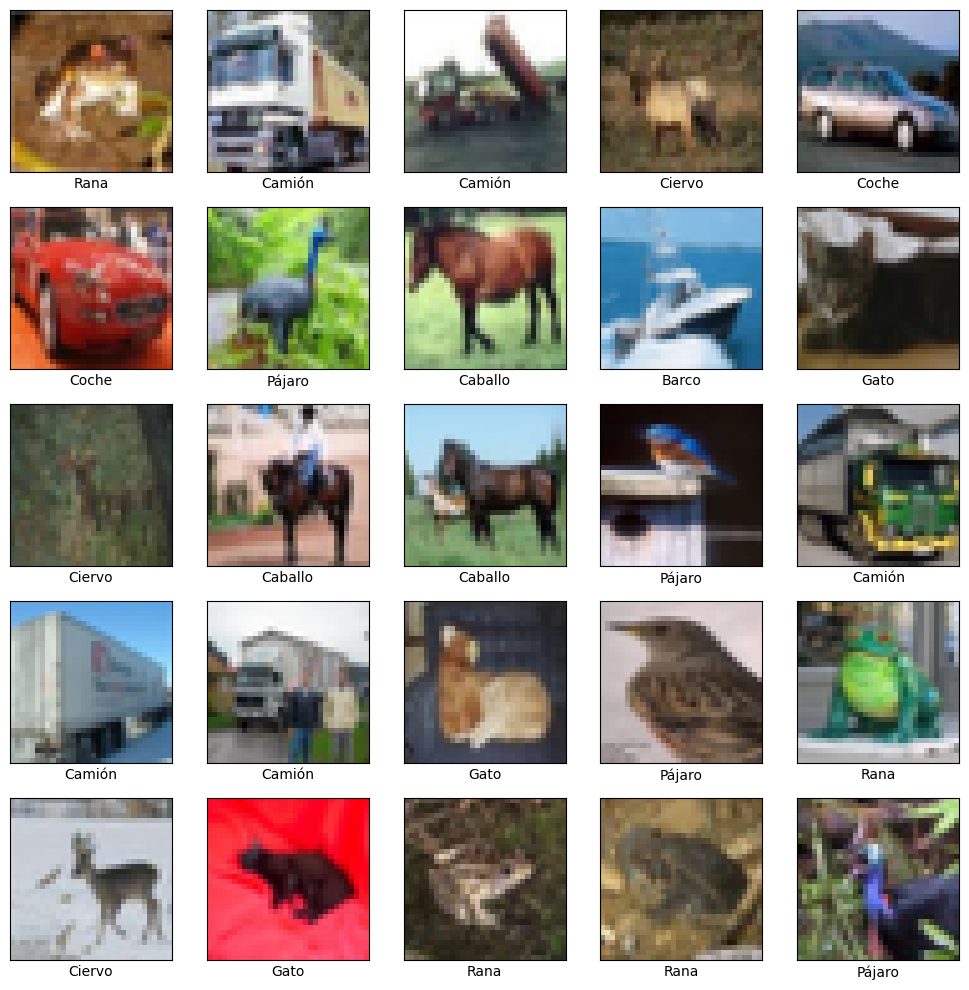

In [7]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train_full[i])
    label_index = int(y_train_full[i][0])
    plt.xlabel(CLASS_NAMES[label_index])
plt.tight_layout()
plt.show()

#### 2.2. Análisis de Dimensiones y Formato

In [8]:
# Verificamos las dimensiones de los arrays
print(f"Formato de las imágenes de entrenamiento (X): {x_train_full.shape}")
print(f"Formato de las etiquetas de entrenamiento (Y): {y_train_full.shape}")
print(f"Formato de las imágenes de test (X): {x_test.shape}")
print(f"Formato de las etiquetas de test (Y): {y_test.shape}")

# Verificamos los tipos de datos
print(f"\nTipo de dato de las imágenes: {x_train_full.dtype}")
print(f"Tipo de dato de las etiquetas: {y_train_full.dtype}")

# Verificamos el rango de valores de los píxeles (importante para el paso 3 de normalización)
print(f"\nValor mínimo de un píxel: {x_train_full.min()}")
print(f"Valor máximo de un píxel: {x_train_full.max()}")

# Observación sobre las etiquetas
print(f"\nEjemplo de las primeras 5 etiquetas brutas:\n{y_train_full[:5]}")
print("Nota: Vemos que las etiquetas tienen forma (N, 1). En el preprocesamiento será útil aplanarlas a (N,).")

Formato de las imágenes de entrenamiento (X): (50000, 32, 32, 3)
Formato de las etiquetas de entrenamiento (Y): (50000, 1)
Formato de las imágenes de test (X): (10000, 32, 32, 3)
Formato de las etiquetas de test (Y): (10000, 1)

Tipo de dato de las imágenes: uint8
Tipo de dato de las etiquetas: uint8

Valor mínimo de un píxel: 0
Valor máximo de un píxel: 255

Ejemplo de las primeras 5 etiquetas brutas:
[[6]
 [9]
 [9]
 [4]
 [1]]
Nota: Vemos que las etiquetas tienen forma (N, 1). En el preprocesamiento será útil aplanarlas a (N,).


#### 2.3. Distribución de Clases

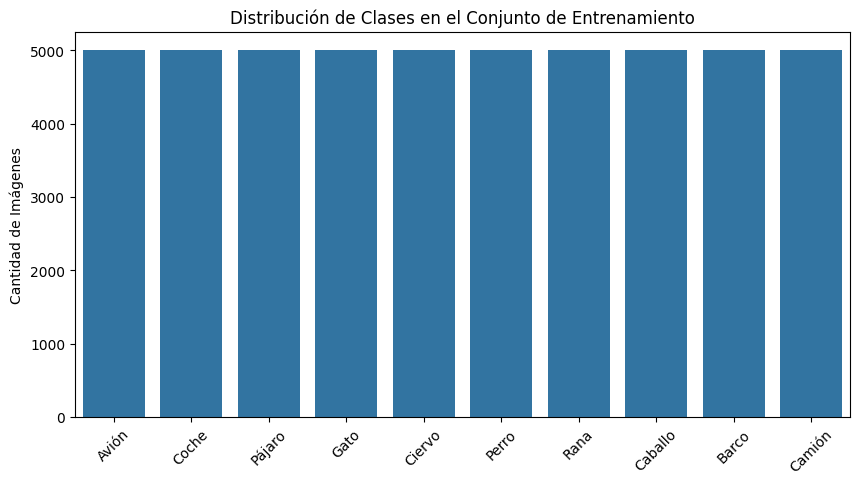

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_full.flatten())
plt.title('Distribución de Clases en el Conjunto de Entrenamiento')
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45)
plt.ylabel('Cantidad de Imágenes')
plt.show()


## 3. PREPROCESAMIENTO DE DATOS

In [10]:
print("\n--- 3. Preprocesamiento de Datos ---")


--- 3. Preprocesamiento de Datos ---


**Justificación:**
* **División (Split):** CIFAR-10 trae un conjunto de entrenamiento (50k) y uno de test (10k). Extraeremos un 20% del entrenamiento para crear un **conjunto de validación**. Esto nos permitirá monitorizar el *overfitting* sin tocar los datos de test hasta el final.
* **Normalización:** Las imágenes tienen valores de píxeles entre 0 y 255. Las redes neuronales convergen mucho más rápido y son más estables matemáticamente si estos valores se escalan a un rango entre 0 y 1.

#### 3.1. División en Train / Validation / Test

In [11]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

print(f"Imágenes para entrenamiento: {x_train.shape[0]}")
print(f"Imágenes para validación: {x_val.shape[0]}")
print(f"Imágenes para test: {x_test.shape[0]}")

Imágenes para entrenamiento: 40000
Imágenes para validación: 10000
Imágenes para test: 10000


#### 3.2. Normalización / Escalado

In [12]:
# Convertimos a float32 para la división
x_train_norm = x_train.astype('float32') / 255.0
x_val_norm = x_val.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Aplastamos las etiquetas para que tengan forma (N,) en lugar de (N, 1)
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

## 4. MODELO 1: CNN DESDE CERO

In [13]:
print("\n--- 4. Modelo 1: CNN desde Cero ---")


--- 4. Modelo 1: CNN desde Cero ---


**Justificación de la arquitectura:** Construiremos una CNN clásica estilo VGG-mini. 
* **Capas Convolucionales:** Tres bloques convolucionales. Cada bloque incrementa los filtros (32 -> 64 -> 128) para detectar patrones cada vez más complejos. Usamos activación `ReLU` por su eficiencia para evitar el desvanecimiento del gradiente.
* **Max Pooling:** Reduce la dimensionalidad espacial, extrayendo las características más dominantes y reduciendo la carga computacional.
* **Clasificador final:** Capa `Flatten` seguida de una `Dense` y finalmente una capa `Softmax` de 10 neuronas para obtener la probabilidad de cada clase.
* **Compilación:** Usamos el optimizador `Adam` (muy eficiente adaptando la tasa de aprendizaje) y `sparse_categorical_crossentropy` (ideal porque nuestras etiquetas son números enteros, no *one-hot encoded*).
* **Early Stopping:** Evitará que el modelo siga entrenando si la pérdida de validación empeora, ahorrando tiempo y previniendo el sobreajuste.

#### 4.1. Construcción de la Arquitectura

In [14]:
model_scratch = Sequential([
    layers.InputLayer(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
    
    # Bloque 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Clasificador
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

I0000 00:00:1773561485.515519     944 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6094 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


#### 4.2. Compilación del Modelo

In [15]:
model_scratch.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

model_scratch.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

#### 4.3. Entrenamiento del Modelo

In [16]:
print("\nEntrenando Modelo desde Cero...")
history_scratch = model_scratch.fit(
    x_train_norm, y_train,
    epochs=EPOCHS_SCRATCH,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_norm, y_val),
    callbacks=[early_stop],
    verbose=1
)


Entrenando Modelo desde Cero...
Epoch 1/30


I0000 00:00:1773561488.718978    2348 service.cc:153] XLA service 0x7fbb140057f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773561488.719014    2348 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1773561488.810384    2348 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773561489.045916    2348 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1773561489.061190    2348 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1871__.39


 26/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1159 - loss: 2.2980

I0000 00:00:1773561493.253911    2348 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4550 - loss: 1.4938 - val_accuracy: 0.6001 - val_loss: 1.1364
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6275 - loss: 1.0585 - val_accuracy: 0.6627 - val_loss: 0.9714
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ -4s 6ms/step - accuracy: 0.6880 - loss: 0.8872 - val_accuracy: 0.6773 - val_loss: 0.9076
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7272 - loss: 0.7789 - val_accuracy: 0.6994 - val_loss: 0.8610
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7591 - loss: 0.6937 - val_accuracy: 0.7176 - val_loss: 0.8199
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7860 - loss: 0.6128 - val_accuracy: 0.7144 - val_loss: 0.8435
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8095 - loss: 0.5527 - val_accuracy: 0.7172 - val_loss: 0.8583
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8278 - loss: 0.4920 - val_accuracy: 0.7043 - 

#### 4.4. Evaluación del Modelo


Evaluación en Test (Modelo desde Cero):
Accuracy en Test: 0.7150


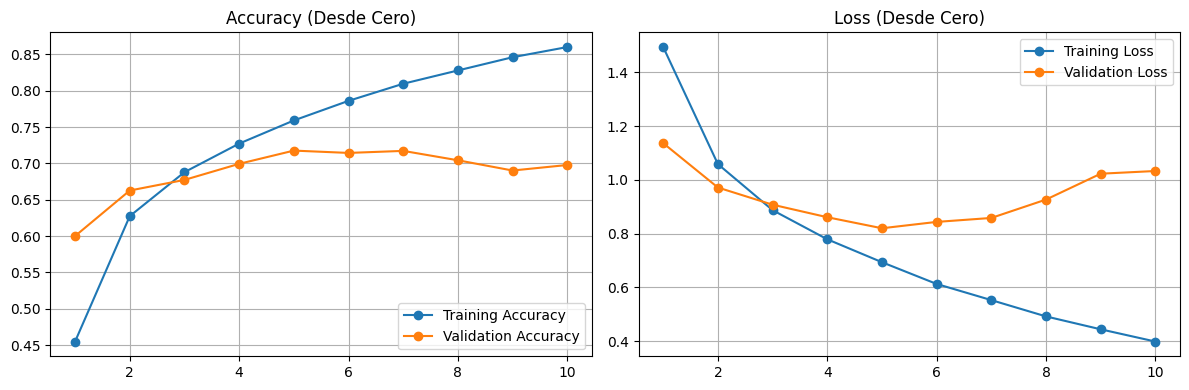

In [17]:
print("\nEvaluación en Test (Modelo desde Cero):")
test_loss_1, test_acc_1 = model_scratch.evaluate(x_test_norm, y_test, verbose=0)
print(f"Accuracy en Test: {test_acc_1:.4f}")

plot_learning_curves(history_scratch, title_suffix='(Desde Cero)')


## 5. MODELO 2: MEJORAS (DATA AUGMENTATION / CLASS WEIGHTING)

In [18]:
print("\n--- 5. Modelo 2: Mejoras (Data Augmentation / Class Weighting) ---")


--- 5. Modelo 2: Mejoras (Data Augmentation / Class Weighting) ---


**Justificación:**
El EDA demostró que el dataset está perfectamente balanceado (5000 imágenes por clase), por lo que *no* necesitamos aplicar pesos de clase. 
Sin embargo, el modelo anterior probablemente haya sufrido algo de sobreajuste (overfitting). Para mitigarlo y mejorar la robustez, introduciremos **Data Augmentation** insertando capas de aumento espacial directamente al inicio de la red neuronal, junto con una capa de **Dropout** antes del clasificador final para forzar a la red a no depender de unas pocas neuronas.

#### 5.1. Cálculo de Pesos de Clase (si hay desbalanceo)

#### 5.2. Definición de Data Augmentation

In [19]:
#data_augmentation = Sequential([
#  layers.RandomFlip("horizontal", input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
# layers.RandomRotation(0.1),
# layers.RandomZoom(0.1),
#])


# Reducimos la agresividad del aumento. Fuera rotaciones y zoom excesivo que en imagenes tan "pixeladas" provocan que se desfiguren y meten ruido al modelo reduciendo su eficacia.
data_augmentation = Sequential([
  layers.RandomFlip("horizontal", input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
  layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode='nearest')
])

#### 5.3. Construcción y Entrenamiento del Modelo Mejorado

In [ ]:
# model_aug = Sequential([
#     data_augmentation,
    
#     layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     layers.Flatten(),
#     layers.Dropout(0.5),
#     layers.Dense(128, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])

# model_aug = Sequential([
#     data_augmentation,
    
#     layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     layers.Flatten(),
#     layers.Dropout(0.25), # Reducimos el apagón de neuronas del 50% al 25%
#     layers.Dense(128, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])

model_aug = Sequential([
    data_augmentation,
    
    # Bloque 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Clasificador
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

early_stop_aug = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print("\nEntrenando Modelo con Data Augmentation y Batch Normalization...")
history_aug = model_aug.fit(
    x_train_norm, y_train,
    epochs=EPOCHS_SCRATCH + 5,  # Le damos un poco más de margen para aprovechar el aumento de datos
    batch_size=BATCH_SIZE,
    validation_data=(x_val_norm, y_val),
    callbacks=[early_stop_aug],
    verbose=1
)



Entrenando Modelo con Data Augmentation y Batch Normalization...
Epoch 1/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.5090 - loss: 1.3683 - val_accuracy: 0.5933 - val_loss: 1.1740
Epoch 2/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6372 - loss: 1.0318 - val_accuracy: 0.6443 - val_loss: 1.0240
Epoch 3/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6848 - loss: 0.9041 - val_accuracy: 0.6820 - val_loss: 0.9083
Epoch 4/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7072 - loss: 0.8310 - val_accuracy: 0.6644 - val_loss: 0.9471
Epoch 5/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7268 - loss: 0.7752 - val_accuracy: 0.7084 - val_loss: 0.8303
Epoch 6/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7432 - loss: 0.7269 - val_accuracy: 0.6927 - val_loss: 0.8729
Epoch 7/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7567 - loss: 0.6953 - val_accuracy: 0.7380 - val_loss: 0.7581
Epoch 8/35
625/625 ━━━━━

#### 5.4. Evaluación del Modelo Mejorado


Evaluación en Test (Modelo con Data Augmentation y Batch Normalization):
Accuracy en Test: 0.8038


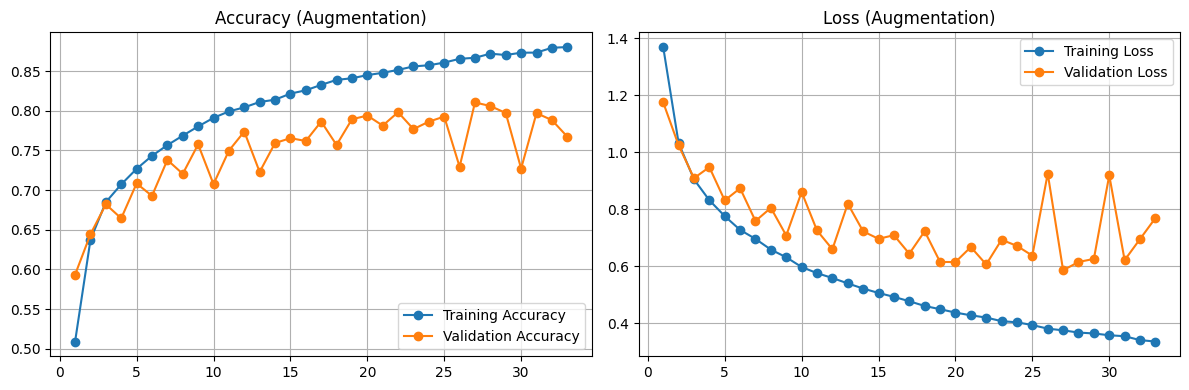

In [21]:
print("\nEvaluación en Test (Modelo con Data Augmentation y Batch Normalization):")
test_loss_2, test_acc_2 = model_aug.evaluate(x_test_norm, y_test, verbose=0)
print(f"Accuracy en Test: {test_acc_2:.4f}")

plot_learning_curves(history_aug, title_suffix='(Augmentation)')

## 6. MODELO 3: TRANSFER LEARNING

In [22]:
print("\n--- 6. Modelo 3: Transfer Learning ---")


--- 6. Modelo 3: Transfer Learning ---


### 6.1. Selección y Carga del Modelo Base Pre-entrenado

**Justificación:**
Para el Transfer Learning utilizaremos **VGG16**, un modelo pre-entrenado en el gigantesco dataset ImageNet.
* **Capas base congeladas:** Importamos VGG16 excluyendo su capa clasificadora original (`include_top=False`). Congelamos sus pesos (`trainable=False`) para actuar puramente como un "extractor de características" de alta calidad, evitando destruir lo que ya aprendió ImageNet.
* **Preprocesamiento:** A diferencia de los modelos anteriores donde escalábamos entre 0 y 1, VGG16 requiere su propia función de preprocesamiento (`preprocess_input` original de Keras), que centra los píxeles respecto a la media de ImageNet. Por lo tanto, usaremos los datos sin la normalización del paso 3.
* **Clasificador:** Añadiremos una capa Flatten y capas densas propias para mapear las características extraídas por VGG16 hacia nuestras 10 clases de CIFAR-10.

In [23]:
# Nota: VGG16 espera el preprocesamiento específico de Caffe, no la normalización 0-1.
# Aplicamos preprocess_input a los datos crudos.
x_train_vgg = preprocess_input(x_train.astype('float32'))
x_val_vgg = preprocess_input(x_val.astype('float32'))
x_test_vgg = preprocess_input(x_test.astype('float32'))

# 6.1. Carga del Modelo Base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Congelar capas
base_model.trainable = False

### 6.2. Creación del Nuevo Modelo (Base + Clasificador Propio)

In [24]:
# model_tl = Sequential([
#     base_model,
#     layers.Flatten(),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(10, activation='softmax')
# ])

# model_tl.summary()

model_tl = Sequential([
    layers.InputLayer(shape=(32, 32, 3)),
    layers.UpSampling2D(size=(3,3)), # Agrandamos la imagen de 32x32 a 96x96
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_tl.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ up_sampling2d (UpSampling2D)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,897,162 (60.64 MB)

 Trainable params: 1,182,474 (4.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 6.3. Compilación y Entrenamiento (solo del clasificador)

In [25]:
model_tl.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop_trans = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print("\nEntrenando clasificador sobre VGG16...")
history_tl = model_tl.fit(
    x_train_vgg, y_train,
    epochs=EPOCHS_TRANSFER,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_vgg, y_val),
    callbacks=[early_stop_trans],
    verbose=1
)


Entrenando clasificador sobre VGG16...
Epoch 1/20


I0000 00:00:1773561929.542898    2348 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_147636__.66


625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.5811 - loss: 1.5914 - val_accuracy: 0.7329 - val_loss: 0.8049
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.6925 - loss: 0.9369 - val_accuracy: 0.7693 - val_loss: 0.7041
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.7326 - loss: 0.8002 - val_accuracy: 0.7851 - val_loss: 0.6634
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.7573 - loss: 0.7173 - val_accuracy: 0.7958 - val_loss: 0.6492
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.7761 - loss: 0.6645 - val_accuracy: 0.8002 - val_loss: 0.6413
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7883 - loss: 0.6222 - val_accuracy: 0.8002 - val_loss: 0.6399
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7994 - loss: 0.5938 - val_accuracy: 0.7999 - val_loss: 0.6849
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8090 - loss: 0.5658 - val_accurac

### 6.4. Evaluación del Modelo de Transfer Learning



Evaluación en Test (Transfer Learning):
Accuracy en Test: 0.8000


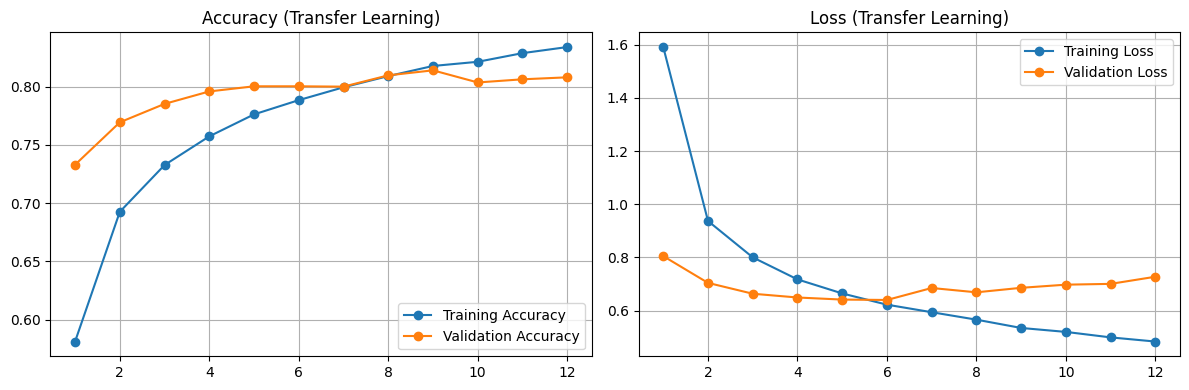

In [26]:
print("\nEvaluación en Test (Transfer Learning):")
test_loss_3, test_acc_3 = model_tl.evaluate(x_test_vgg, y_test, verbose=0)
print(f"Accuracy en Test: {test_acc_3:.4f}")

plot_learning_curves(history_tl, title_suffix='(Transfer Learning)')

### 6.5. Fine-Tuning (Opcional)


Clonando el modelo Transfer Learning...

Entrenando Modelo 4 (TL + Fine-Tuning)...
Epoch 1/10


I0000 00:00:1773562439.180951    2346 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_190650__.66


625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 82ms/step - accuracy: 0.8235 - loss: 0.5124 - val_accuracy: 0.8326 - val_loss: 0.5593
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8587 - loss: 0.4082 - val_accuracy: 0.8419 - val_loss: 0.5384
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8781 - loss: 0.3433 - val_accuracy: 0.8503 - val_loss: 0.5248
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8934 - loss: 0.2934 - val_accuracy: 0.8550 - val_loss: 0.5258
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 66ms/step - accuracy: 0.9093 - loss: 0.2500 - val_accuracy: 0.8618 - val_loss: 0.5275
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9168 - loss: 0.2253 - val_accuracy: 0.8644 - val_loss: 0.5278

Evaluación en Test (TL + Fine-Tuning):
Accuracy en Test: 0.8538


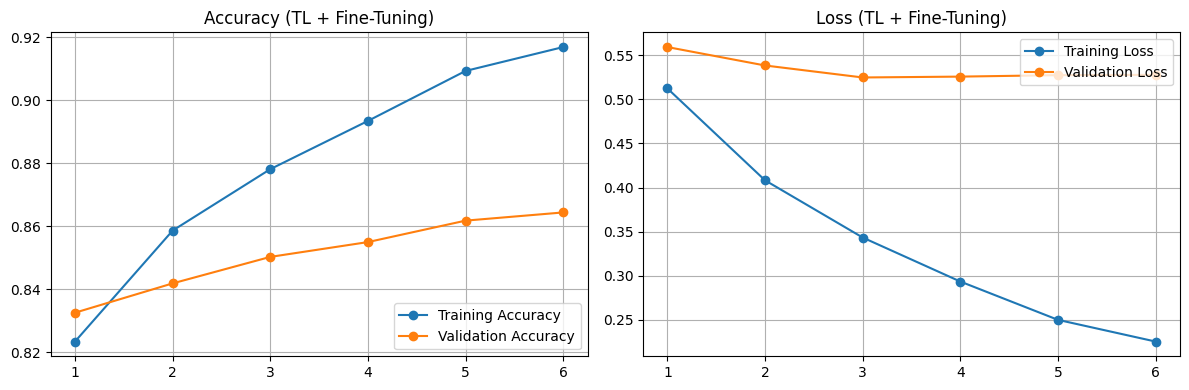

In [27]:
#Clonamos el modelo para poder comparar resultados (de otra forma estaríamos pisando los resultados del model_tl)
print("\nClonando el modelo Transfer Learning...")
model_ft = clone_model(model_tl)
model_ft.set_weights(model_tl.get_weights())

# Buscamos el bloque de VGG16 dentro del modelo clonado y descongelamos solo el 'block5'
for layer in model_ft.layers:
    if layer.name == 'vgg16': # Nombre por defecto de la capa del base_model
        layer.trainable = True
        for sub_layer in layer.layers:
            if sub_layer.name.startswith('block5'):
                sub_layer.trainable = True
            else:
                sub_layer.trainable = False


# Es necesario compilar de nuevo el modelo después de cambiar "trainable"
# Learning_rate bajo para no destruir los pesos pre-entrenados
model_ft.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("\nEntrenando Modelo 4 (TL + Fine-Tuning)...")
early_stop_ft = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entrenamos unas pocas épocas más
history_ft = model_ft.fit(
    x_train_vgg, y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_vgg, y_val),
    callbacks=[early_stop_ft],
    verbose=1
)

print("\nEvaluación en Test (TL + Fine-Tuning):")

test_loss_4, test_acc_4 = model_ft.evaluate(x_test_vgg, y_test, verbose=0)
print(f"Accuracy en Test: {test_acc_4:.4f}")
plot_learning_curves(history_ft, title_suffix='(TL + Fine-Tuning)')

## 7. COMPARACIÓN DE MODELOS Y CONCLUSIONES

In [28]:
print("\n--- 7. Comparación y Conclusiones ---")


--- 7. Comparación y Conclusiones ---


### 7.1. Tabla Comparativa de Resultados

In [29]:
# Generar predicciones
preds_scratch = np.argmax(model_scratch.predict(x_test_norm), axis=-1)
preds_aug = np.argmax(model_aug.predict(x_test_norm), axis=-1)
preds_tl = np.argmax(model_tl.predict(x_test_vgg), axis=-1)
preds_ft = np.argmax(model_ft.predict(x_test_vgg), axis=-1)

# Reportes detallados
print("\nClassification Report (Modelo Scratch):\n")
print(classification_report(y_test, preds_scratch, target_names=CLASS_NAMES))

print("\nClassification Report (Modelo Mejorado):\n")
print(classification_report(y_test, preds_aug, target_names=CLASS_NAMES))

print("\nClassification Report (Modelo Transfer):\n")
print(classification_report(y_test, preds_tl, target_names=CLASS_NAMES))

print("\nClassification Report (Modelo TL + Fine-Tuning):\n")
print(classification_report(y_test, preds_ft, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step

Classification Report (Modelo Scratch):

              precision    recall  f1-score   support

       Avión       0.70      0.81      0.75      1000
       Coche       0.80      0.85      0.83      1000
      Pájaro       0.63      0.58      0.60      1000
        Gato       0.55      0.47      0.51      1000
      Ciervo       0.60      0.69      0.64      1000
       Perro       0.63      0.63      0.63      1000
        Rana       0.84      0.76      0.80      1000
     Caballo       0.76      0.77      0.76      1000
       Barco       0.84      0.81      0.82      1000
      Camión       0.82      0.79      0.80      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000


Classification Report (Modelo 


Matrices de Confusión de los 4 Modelos:


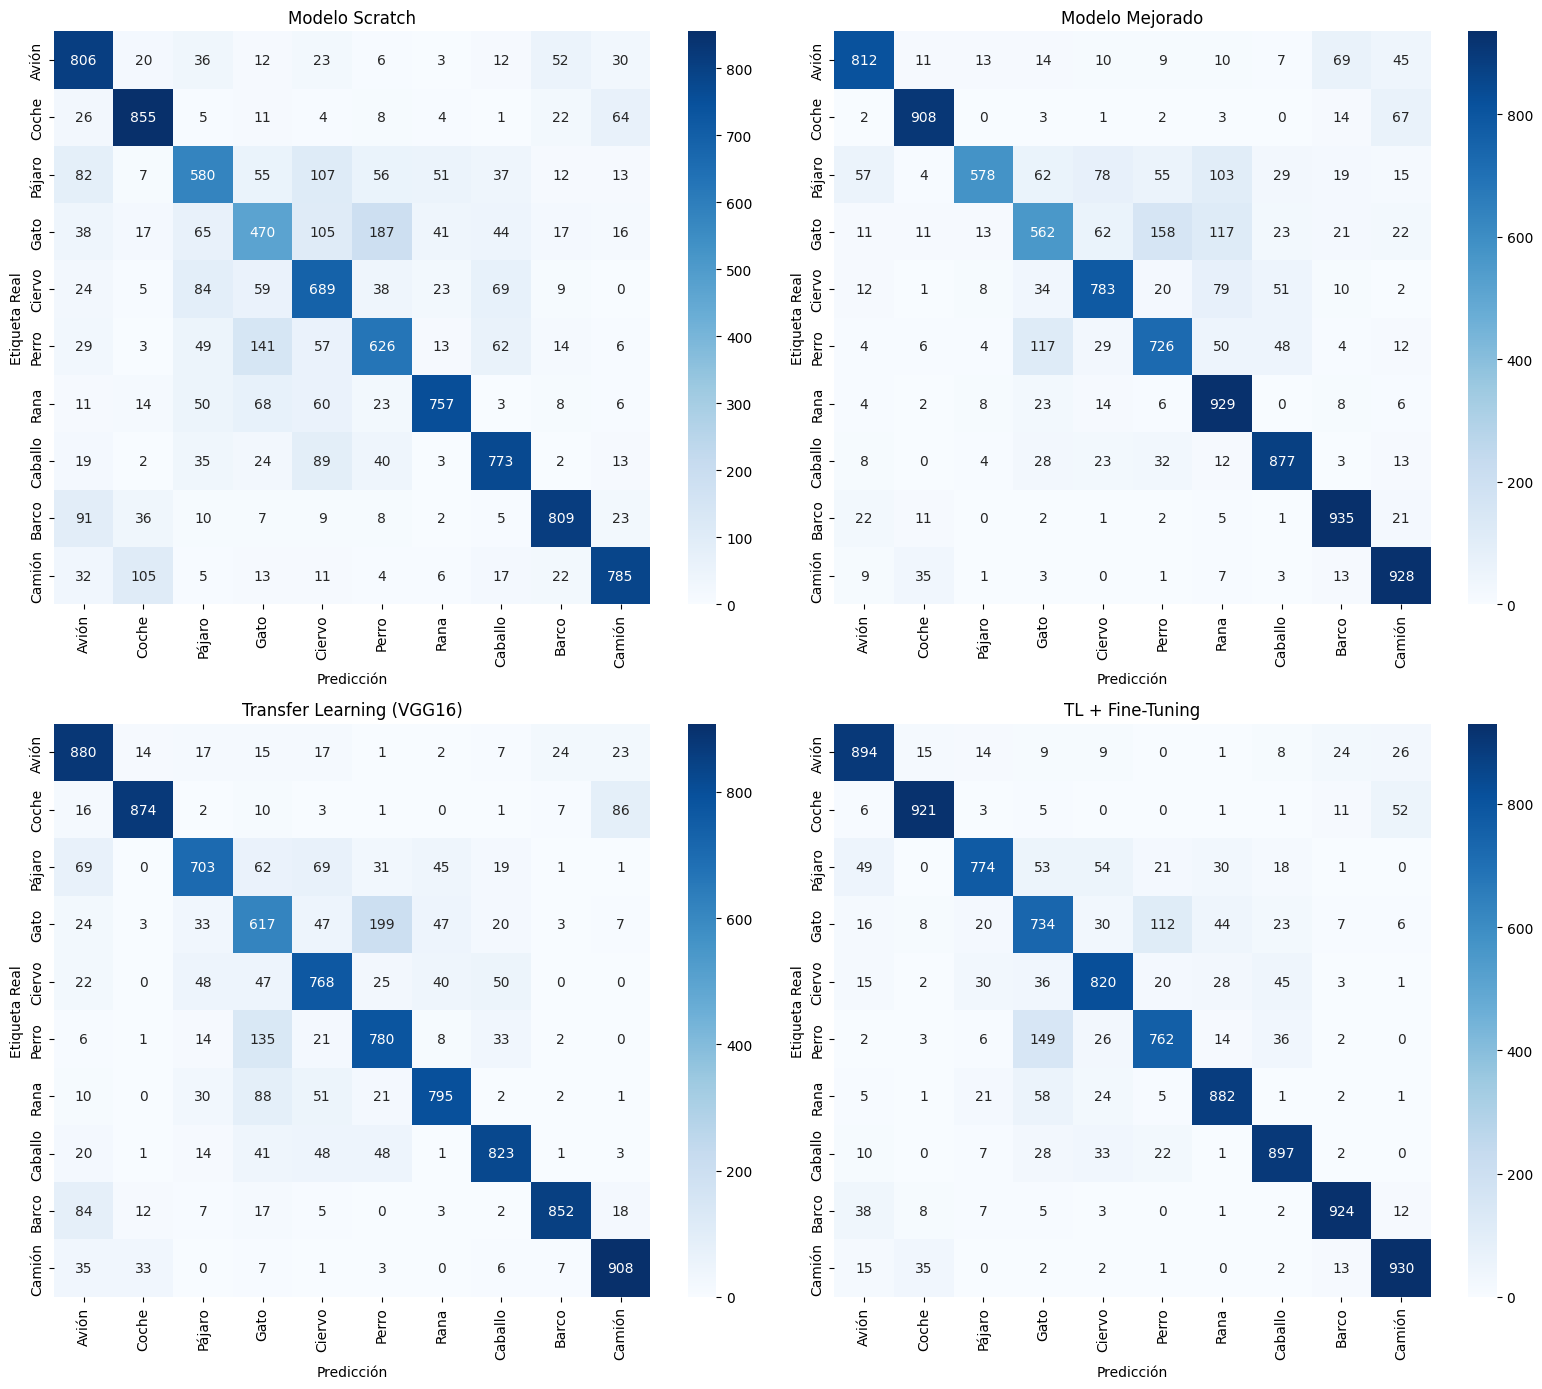

In [30]:
print("\nMatrices de Confusión de los 4 Modelos:")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plot_confusion_matrix(y_test, preds_scratch, 'Modelo Scratch', axes[0,0])
plot_confusion_matrix(y_test, preds_aug, 'Modelo Mejorado', axes[0,1])
plot_confusion_matrix(y_test, preds_tl, 'Transfer Learning (VGG16)', axes[1,0])
plot_confusion_matrix(y_test, preds_ft, 'TL + Fine-Tuning', axes[1,1])
plt.tight_layout()
plt.show()

In [31]:
# DataFrame con todos los resultados
resultados = pd.DataFrame({
    'Modelo': ['CNN Scratch', 'CNN Data Aug.', 'Transfer Learning (VGG16)', 'TL + Fine-Tuning'],
    'Test Loss': [test_loss_1, test_loss_2, test_loss_3, test_loss_4],
    'Test Accuracy': [test_acc_1, test_acc_2, test_acc_3, test_acc_4]
})
print("\nResumen Comparativo de Modelos:")
display(resultados)


Resumen Comparativo de Modelos:


,Modelo,Test Loss,Test Accuracy
0,CNN Scratch,0.832138,0.7150
1,CNN Data Aug.,0.626022,0.8038
2,Transfer Learning (VGG16),0.636811,0.8000
3,TL + Fine-Tuning,0.521045,0.8538


### 7.2. Discusión y Conclusiones Finales

**1. Rendimiento General de los Modelos**
De todos los modelos que he probado, el ganador absoluto ha sido el modelo de **Transfer Learning al que le he aplicado Fine-Tuning** (Modelo 4), consiguiendo un **85% de precisión** en los datos de test. En segundo lugar quedaría la CNN que hice con **Data Augmentation** (Modelo 2) con un muy buen **80%**. Me llamaba la atención que, en un primer momento, el modelo VGG16 "congelado" (Modelo 3, 80%) no superaba a mi red CNN. Creo que esto se debe a que VGG16 está entrenado con imágenes más grandes (de 224x224 píxeles de *ImageNet*), y sus "filtros" no estaban del todo acoplados para imágenes tan pixeladas como las de CIFAR-10 (solo 32x32 píxeles).

**2. Curvas de Aprendizaje y el Data Augmentation**
Al evaluar el primer modelo (el que hice desde cero, que sacó un **71%**), vi claramente que sufría de *overfitting*, la red se memorizaba los datos de entrenamiento pero luego se equivocaba más en la validación. Para solucionarlo, usé el **Data Augmentation** (volteando y moviendo un poco las imágenes en cada época). Esta fue una de las mejores decisiones, ayudó muchísimo a que el modelo aprendiera patrones generales y no de forma memorística, logrando saltar directamente al 80% de Accuracy y bajando bastante el "Test Loss".

**3. Transfer Learning y Tiempo de Entrenamiento**
Usar Transfer Learning (Modelo 3) fue útil porque te saltas la fase de entrenar toda la red desde cero. Al aprovechar lo que la red VGG16 ya sabe pre-entrenada para identificar formas o colores básicos, solo tuve que enseñar a la última capa a clasificar las 10 categorías de CIFAR. Aunque entrenaba más rápido que mi propia red CNN, sus resultados directos se estancaron en el 80% por culpa de lo que hablé antes sobre el tamaño de las imágenes.

**4. ¿Valió la pena el Fine-Tuning?**
Sí, sin duda, **ha sido clave en la práctica**. Para mejorar el Transfer Learning base (Modelo 3), hice el **Fine-Tuning** (Modelo 4). Lo que hice fue "descongelar" el último bloque convolucional de VGG16 y dejé que también aprendiera un poquito con mis imágenes usando un *learning rate* muy bajo (1e-5) para no destruir lo que ya sabía de entrada. Fue el toque mágico final para que VGG16 se adaptase a este problema en concreto, disparando el modelo hasta ese 85%.

**5. Desafíos y Siguientes Pasos**
El mayor quebradero de cabeza fue darme cuenta de que la rotación y el zoom de la primera prueba de data augmentation estaban destruyendo las imagenes de 32x32 y generando un mál entrenamiento del modelo. También me di cuenta de que si usas Transfer Learning, no puedes normalizar las imágenes simplemente dividiéndolas entre 255.0 (como hacía en los otros), sino que VGG16 necesita su propio código especial (`preprocess_input`). Como siguientes pasos, me gustaría probar otras redes pre-entrenadas muchísimo más ligeras e ideales para imágenes pequeñas o uso móvil, como por ejemplo la arquitectura *MobileNetV2* o *EfficientNet*.

In [32]:

print("\n--- Fin del Proyecto ---")


--- Fin del Proyecto ---
